<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/nn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import torch
from sklearn.datasets import make_circles
import sklearn
from torch import nn
import numpy as np

In [46]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=13)

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [48]:
print(len(X), len(y))
print(X[:5], y[:5])
print(X[:5, 1])

1000 1000
[[ 0.64375185 -0.50570051]
 [ 0.77505607 -0.58490191]
 [-0.80262167 -0.65301687]
 [ 0.65022982 -0.74086064]
 [-0.09074853 -0.79134821]] [1 0 0 0 1]
[-0.50570051 -0.58490191 -0.65301687 -0.74086064 -0.79134821]


In [49]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "y": y})
circles.head()

,X1,X2,y
0,0.643752,-0.505701,1
1,0.775056,-0.584902,0
2,-0.802622,-0.653017,0
3,0.650230,-0.740861,0
4,-0.090749,-0.791348,1


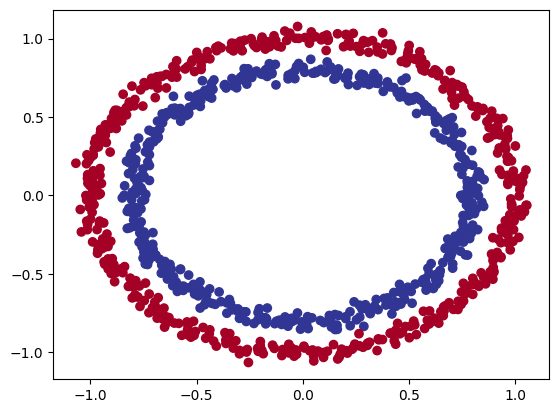

In [50]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0], y=X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [51]:
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float().reshape(-1, 1)
X.shape, y.shape, X.dtype, y.dtype, X.device, y.device

(torch.Size([1000, 2]),
 torch.Size([1000, 1]),
 torch.float32,
 torch.float32,
 device(type='cpu'),
 device(type='cpu'))

In [52]:
X = X.to(device)
y = y.to(device)
X.device, y.device

(device(type='cuda', index=0), device(type='cuda', index=0))

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.cpu(), y.cpu(), train_size=0.8, random_state=13, stratify=y.cpu())
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

In [54]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_train.dtype, y_test.dtype, X_train.device, y_test.device

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800, 1]),
 torch.Size([200, 1]),
 torch.float32,
 torch.float32,
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [55]:
## Create Model
class CircleClassifierModel_0(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(2, 5),
        nn.Linear(5, 1)
    )

  def forward(self, x):
    return self.network(x)

In [56]:
class SquaredParametersModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Linear(5,1)

  def forward(self, x):
    x_full = torch.cat((x, torch.square(x), (x[:,0] * x[:,1]).reshape(-1,1)), dim=1)
    return self.network(x_full)

In [57]:
model_0 = CircleClassifierModel_0().to(device)
model_1 = nn.Linear(2,1)
model_2 = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16,8),
    nn.ReLU(),
    nn.Linear(8, 1)
)
model_3 = nn.Sequential(
    nn.Linear(2, 32),
    nn.Sigmoid(),
    nn.Linear(32, 32),
    nn.Sigmoid(),
    nn.Linear(32, 1)
)
model_4 = nn.Sequential(
    nn.Linear(2, 64),
    nn.Sigmoid(),
    nn.Linear(64, 1)
)
model_5 = nn.Sequential(
    nn.Linear(2, 256),
    nn.Sigmoid(),
    nn.Linear(256,1)
)
model_6 = SquaredParametersModel().to(device)
loss_fn = nn.BCEWithLogitsLoss()

In [58]:
def train_model(epochs=100, lr=0.01, model=model_0, loss_fn=loss_fn, optimizer_class=torch.optim.Adam, device=device):

  optimizer = optimizer_class(params=model.parameters(), lr=lr)

  model.to(device)

  epoch_count = []
  train_loss_history = []
  test_loss_history = []

  for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
      test_logits = model(X_test)
      test_loss = loss_fn(test_logits, y_test)

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_history.append(loss.item())
      test_loss_history.append(test_loss.item())

  return (epoch_count, train_loss_history, test_loss_history)

In [59]:
print(next(model_6.parameters()).device)
print(device)
# epoch_count, train_loss_history, test_loss_history = train_model(epochs=1000, lr=0.005, model=model_4)

cuda:0
cuda


In [66]:
models_dict = {
    "linear_model_0": model_0,
    "linear_model_1": model_1,
    "relu_model_2": model_2,
    "sigmoid_two_layers_model_3": model_3,
    "single_sigmoid_64_model_4": model_4,
    "single_sigmoid_256_model_5": model_5,
    "linear_with_squars_model_6": model_6
}
# Use untrained models for plot_learning_curves - they're trained inside. otherwise its misleading as a model could get trained multiple times

In [67]:
from matplotlib.patches import Patch
def plot_learning_curves(models_dict=models_dict, epoch_count=[], train_loss_history=[], test_loss_history=[]):
  plt.figure(figsize=(10,6))
  colors = plt.cm.tab10(np.linspace(0,1,len(models_dict)))
  legend_handles = []

  for color, (model_name, model) in zip(colors, models_dict.items()):
    epoch_count, train_loss_history, test_loss_history = train_model(epochs=1000, lr=0.005, model=model)
    plt.plot(epoch_count, train_loss_history, c=color, linestyle="-")
    plt.plot(epoch_count, test_loss_history, c=color, linestyle="--")
    legend_handles.append(
        Patch(facecolor=color, label=model_name)
    )

  plt.legend(handles=legend_handles)
  plt.xlabel("epoch")
  plt.ylabel("loss")
  plt.title("Learning Curves")
  plt.show()

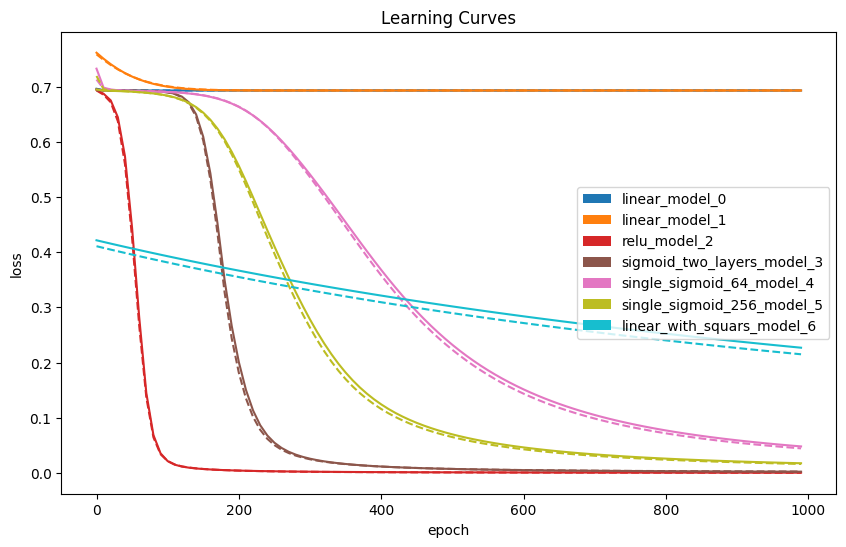

In [68]:
plot_learning_curves()

In [63]:
def accuracy_score(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = (correct / y_true.shape[0]) * 100
  return accuracy

In [69]:
with torch.inference_mode():
  for model_name, model in models_dict.items():
    pred = torch.round(torch.sigmoid(model(X_test)))
    accuracy = accuracy_score(y_test, pred)
    print(f"Accuracy of {model_name}: {accuracy}")

Accuracy of linear_model_0: 49.5
Accuracy of linear_model_1: 49.5
Accuracy of relu_model_2: 100.0
Accuracy of sigmoid_two_layers_model_3: 100.0
Accuracy of single_sigmoid_64_model_4: 100.0
Accuracy of single_sigmoid_256_model_5: 100.0
Accuracy of linear_with_squars_model_6: 100.0


In [70]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


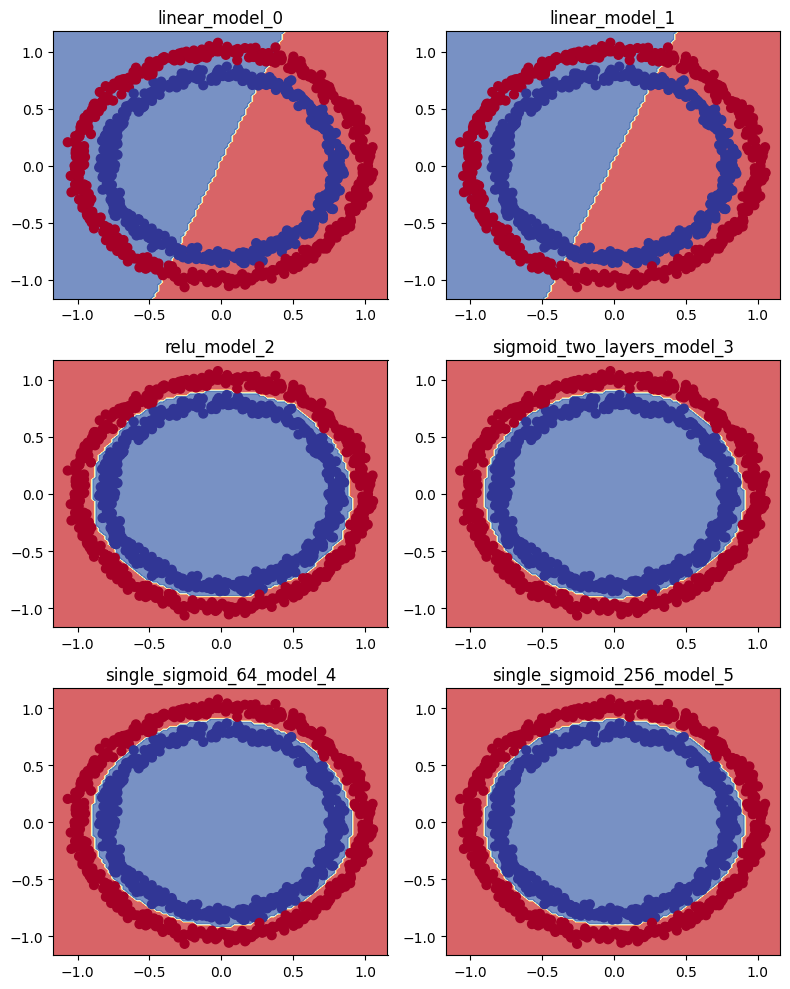

In [81]:
fig, axes = plt.subplots(3, 2, figsize=(8,10))
axes = axes.ravel()

for ax, (model_name, model) in zip(axes, models_dict.items()):
    plt.sca(ax)  # Set Current Axes
    plot_decision_boundary(model, X, y)
    ax.set_title(model_name)

plt.tight_layout()